In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split 
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
import os

# Define the path to the dataset
dataset_dir = '/kaggle/input/plant-diseases-training-dataset'  # Replace with the path to your dataset

# Supported image formats
VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg')

# Function to count images in each subfolder
def count_images_and_folders(dataset_dir):
    folder_image_count = {}
    folder_names = []  # To store all subfolder names

    # Walk through the dataset directory
    for root, subdirs, files in os.walk(dataset_dir):
        if root != dataset_dir:  # Skip the root directory
            folder_name = os.path.basename(root)
            folder_names.append(folder_name)

            # Count valid image files
            image_count = sum(1 for file in files if file.lower().endswith(VALID_EXTENSIONS))
            folder_image_count[folder_name] = image_count

    # Print the total number of folders
    print(f"Number of Total Folders: {len(folder_names)}")

    # Print the number of images in each folder
    for folder, count in folder_image_count.items():
        print(f"Folder: {folder}, Images: {count}")

    return folder_image_count

# Call the function
image_counts = count_images_and_folders(dataset_dir)


Number of Total Folders: 62
Folder: data, Images: 0
Folder: Corn___northern_leaf_blight, Images: 985
Folder: Tomato___late_blight, Images: 1909
Folder: Tomato___healthy, Images: 1591
Folder: Sugercane___mosaic, Images: 462
Folder: Grape___healthy, Images: 1705
Folder: Soybean___healthy, Images: 5090
Folder: Potato___bacterial_wilt, Images: 569
Folder: Squash___powdery_mildew, Images: 1835
Folder: Sugercane___rust, Images: 514
Folder: Tomato___leaf_curl, Images: 5357
Folder: Potato___healthy, Images: 1777
Folder: Cassava___mosaic_disease, Images: 13158
Folder: Apple___alternaria_leaf_spot, Images: 278
Folder: Cassava___brown_streak_disease, Images: 2189
Folder: Rice___blast, Images: 1440
Folder: Grape___Leaf_blight, Images: 1076
Folder: Grape___leaf_blight, Images: 400
Folder: Tomato___early_blight, Images: 1000
Folder: Tomato___septoria_leaf_spot, Images: 1771
Folder: Corn___healthy, Images: 1162
Folder: Strawberry___leaf_scorch, Images: 1109
Folder: Potato___pests, Images: 611
Folder:

In [3]:
import os
import cv2
import numpy as np

# Define paths
input_dir = '/kaggle/input/plant-diseases-training-dataset'  # Replace with the path to your dataset
output_dir = '/kaggle/working/norm_images'  # Replace with the path to save normalized images

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Parameters
IMG_SIZE = (224, 224)  # Resize images to 224x224

# Function to normalize and save images
def normalize_images_recursively(input_dir, output_dir):
    # Walk through the directory structure
    for root, subdirs, files in os.walk(input_dir):
        # Create a corresponding output folder structure
        relative_path = os.path.relpath(root, input_dir)
        output_folder_path = os.path.join(output_dir, relative_path)
        os.makedirs(output_folder_path, exist_ok=True)
        
        for file_name in files:
            file_path = os.path.join(root, file_name)
            output_file_path = os.path.join(output_folder_path, file_name)

            # Process only image files
            if not file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                print(f"Skipping non-image file: {file_path}")
                continue

            try:
                # Read the image
                img = cv2.imread(file_path)
                if img is None:
                    print(f"Skipping {file_path}, unable to read.")
                    continue

                # Resize the image
                img_resized = cv2.resize(img, IMG_SIZE)

                # Normalize the image to [0, 1]
                img_normalized = img_resized / 255.0

                # Convert normalized image back to uint8 format for saving
                img_normalized_uint8 = (img_normalized * 255).astype(np.uint8)

                # Save the normalized image
                cv2.imwrite(output_file_path, img_normalized_uint8)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

    print(f"Normalization complete. Normalized images saved to {output_dir}")

# Call the function to normalize the dataset
normalize_images_recursively(input_dir, output_dir)


Skipping non-image file: /kaggle/input/plant-diseases-training-dataset/index.txt
Normalization complete. Normalized images saved to /kaggle/working/norm_images


In [4]:
import os
import cv2
import numpy as np

# Define paths
input_dir = '/kaggle/working/norm_images'  # Replace with the path to your dataset
output_dir = '/kaggle/working/augmented_images'  # Replace with the path to save augmented images

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Parameters
IMG_SIZE = (224, 224)  # Resize images to 224x224
SHIFT_RATIO = 0.2  # Shift ratio for horizontal and vertical shifts

# Function to augment and save images
def augment_images_recursively(input_dir, output_dir):
    # Walk through the directory structure
    for root, subdirs, files in os.walk(input_dir):
        # Create a corresponding output folder structure
        relative_path = os.path.relpath(root, input_dir)
        output_folder_path = os.path.join(output_dir, relative_path)
        os.makedirs(output_folder_path, exist_ok=True)
        
        for file_name in files:
            file_path = os.path.join(root, file_name)
            output_file_path = os.path.join(output_folder_path, file_name)

            # Process only image files
            if not file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                print(f"Skipping non-image file: {file_path}")
                continue

            try:
                # Read the image
                img = cv2.imread(file_path)
                if img is None:
                    print(f"Skipping {file_path}, unable to read.")
                    continue

                # Resize the image
                img_resized = cv2.resize(img, IMG_SIZE)

                # Denoise the image using Gaussian blur
                img_denoised = cv2.GaussianBlur(img_resized, (5, 5), 0)

                # Horizontal and vertical shifting
                height, width, _ = img_denoised.shape
                tx = int(SHIFT_RATIO * width)  # Horizontal shift
                ty = int(SHIFT_RATIO * height)  # Vertical shift
                
                # Translation matrices
                M_horizontal = np.float32([[1, 0, tx], [0, 1, 0]])
                M_vertical = np.float32([[1, 0, 0], [0, 1, ty]])

                # Apply horizontal and vertical shifts
                img_horizontally_shifted = cv2.warpAffine(img_denoised, M_horizontal, (width, height))
                img_vertically_shifted = cv2.warpAffine(img_denoised, M_vertical, (width, height))

                # Save augmented images
                cv2.imwrite(output_file_path.replace('.jpg', '_denoised.jpg'), img_denoised)
                cv2.imwrite(output_file_path.replace('.jpg', '_horizontal_shift.jpg'), img_horizontally_shifted)
                cv2.imwrite(output_file_path.replace('.jpg', '_vertical_shift.jpg'), img_vertically_shifted)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

    print(f"Augmentation complete. Augmented images saved to {output_dir}")

# Call the function to augment the dataset
augment_images_recursively(input_dir, output_dir)


Augmentation complete. Augmented images saved to /kaggle/working/augmented_images


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from tensorflow.keras.utils import plot_model

# Step 1: Dataset Paths
train_dir = "/kaggle/input/plant-diseases-training-dataset"
test_dir = "/kaggle/input/plant-disease-test-dataset"

In [6]:
# Step 2: Preprocessing
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training')

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation')

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

Found 77837 images belonging to 1 classes.
Found 19459 images belonging to 1 classes.
Found 3461 images belonging to 1 classes.


In [30]:
from keras.applications import MobileNet
from keras.layers import Input, Flatten, Dense, Dropout
from keras.models import Model

# Set image size
img_size = 224  # Update this to your image size
batch_size = 32  # Set your batch size

# Step 1: Define the MobileNet model with no pre-trained weights
base_model = MobileNet(weights=None, include_top=False, input_tensor=Input(shape=(img_size, img_size, 3)))

# Step 2: Add custom layers on top of the base model
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Step 3: Freeze the base model layers (optional if you want to train from scratch)
for layer in base_model.layers:
    layer.trainable = False

# Step 4: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Step 5: Train the model using your data
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_steps=val_generator.samples // batch_size
)


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 112, 112, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)        │ (None, 112, 112, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_relu (ReLU)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1 (DepthwiseConv2D)          │ (None, 112, 112, 32)        │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_bn (BatchNormalization)    │ (None, 112, 112, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_relu (ReLU)                │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1 (Conv2D)                   │ (None, 112, 112, 64)        │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_bn (BatchNormalization)    │ (None, 112, 112, 64)        │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_relu (ReLU)                │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pad_2 (ZeroPadding2D)           │ (None, 113, 113, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2 (DepthwiseConv2D)          │ (None, 56, 56, 64)          │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_bn (BatchNormalization)    │ (None, 56, 56, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_relu (ReLU)                │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2 (Conv2D)                   │ (None, 56, 56, 128)         │           8,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_bn (BatchNormalization)    │ (None, 56, 56, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_relu (ReLU)                │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3 (DepthwiseConv2D)          │ (None, 56, 56, 128)         │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_bn (BatchNormalization)    │ (None, 56, 56, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_relu (ReLU)                │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_3 (Conv2D)                   │ (None, 56, 56, 128)         │          16,384 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 9,651,649 (36.82 MB)

 Trainable params: 6,422,785 (24.50 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/losses/losses.py:27: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored

2432/2432 ━━━━━━━━━━━━━━━━━━━━ 2102s 863ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 1s 67us/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


2432/2432 ━━━━━━━━━━━━━━━━━━━━ 2093s 860ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 1s 35us/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 2059s 847ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 2047s 842ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 1s 74us/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 9/10
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 2018s 829ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 10/10
2432/2432 ━

/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


109/109 ━━━━━━━━━━━━━━━━━━━━ 70s 635ms/step


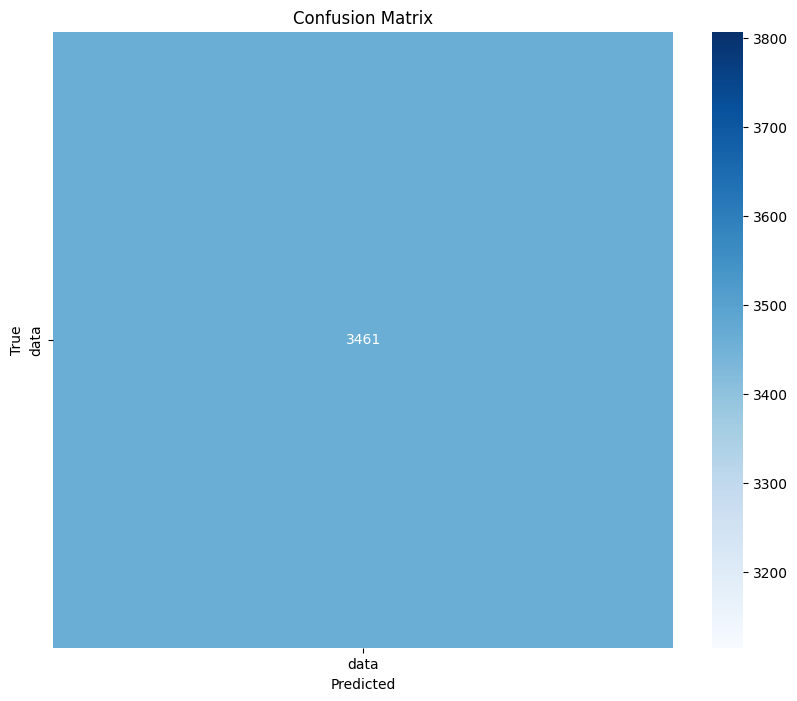

In [31]:
# Step 5: Confusion Matrix
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:1020: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:97: RuntimeWarning: invalid value encountered in less
  if np.any(dx < 0):


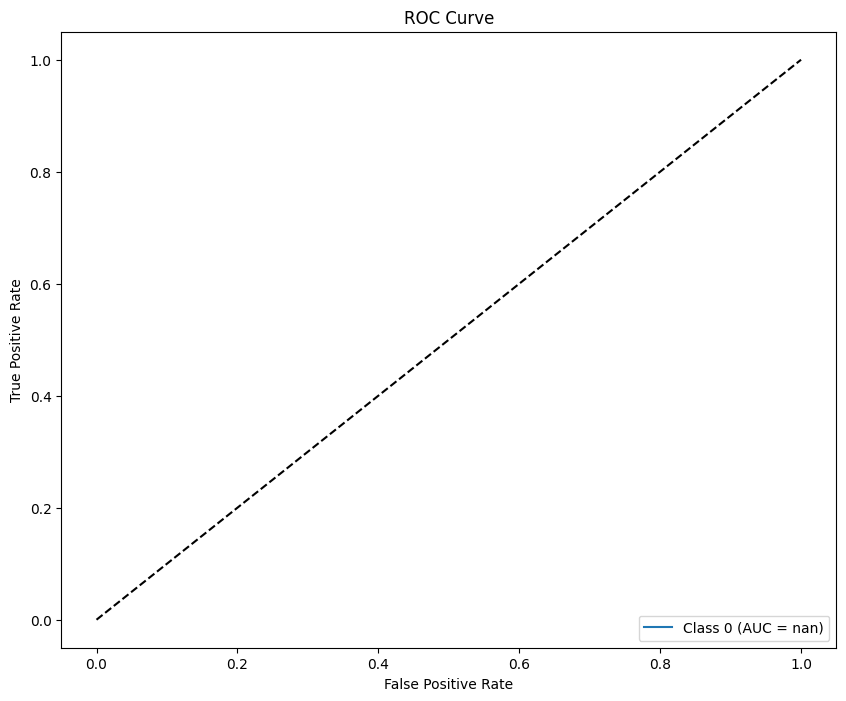

In [32]:
# Step 6: ROC Curve
fpr = {}
tpr = {}
roc_auc = {}
for i in range(train_generator.num_classes):
    fpr[i], tpr[i], _ = roc_curve((y_true == i).astype(int), predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(train_generator.num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

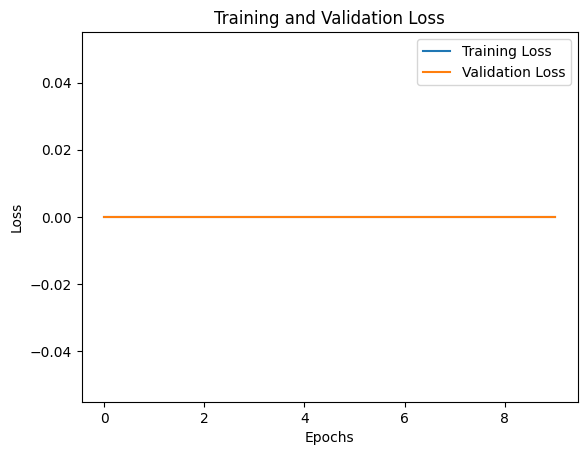

In [33]:
# Step 7: Training and Validation Loss Graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

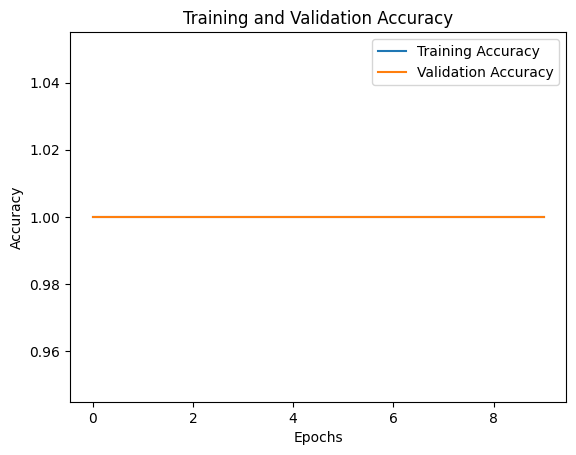

In [34]:
# Step 8: Training and Validation Accuracy Graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

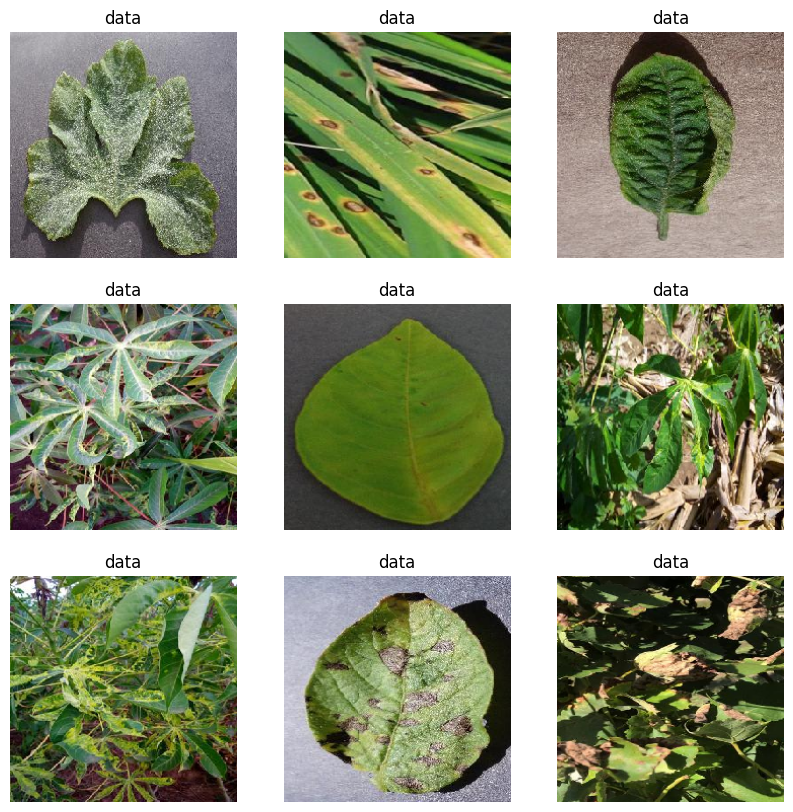

In [36]:
# Step 10: Dataset Images with Labels
sample_images, sample_labels = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_images[i])
    plt.title(list(train_generator.class_indices.keys())[np.argmax(sample_labels[i])])
    plt.axis('off')
plt.show()

Training Dataset Samples:
['index.txt', 'data']
Test Dataset Samples:
['index.txt', 'data']


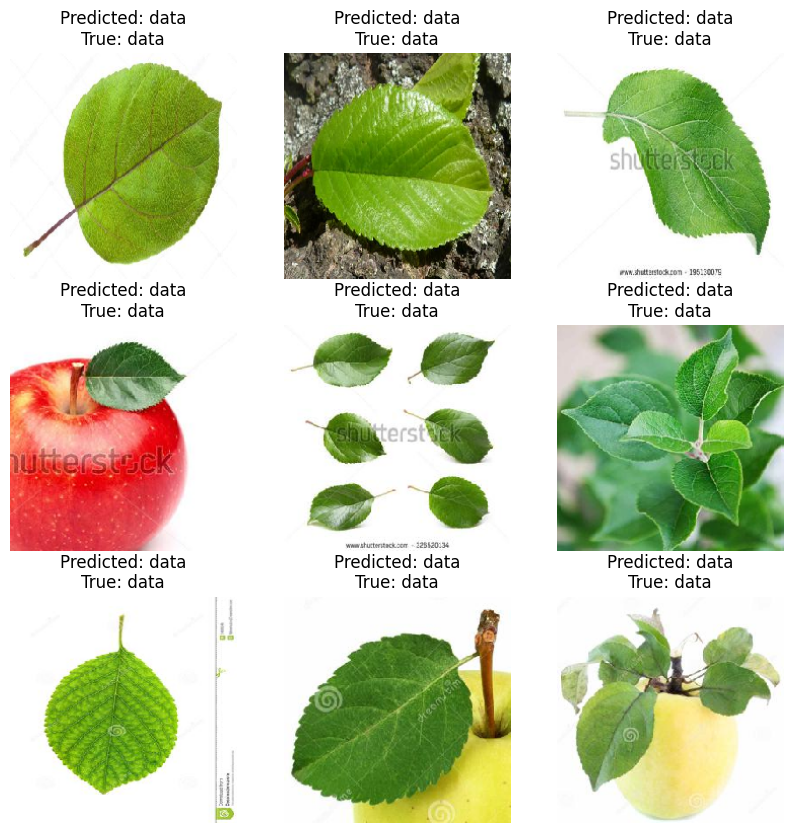

In [37]:
# Step 12: Samples of Dataset
print("Training Dataset Samples:")
print(os.listdir(train_dir))

print("Test Dataset Samples:")
print(os.listdir(test_dir))

# Step 13: Samples of Model Predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(test_generator[0][0][i])
    plt.title(f"Predicted: {list(test_generator.class_indices.keys())[y_pred[i]]}\nTrue: {list(test_generator.class_indices.keys())[y_true[i]]}")
    plt.axis('off')
plt.show()
